# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [130]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

/var/folders/v5/yddrf7t17gj_q1nfvqx_2sfm0000gn/T/ipykernel_94304/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

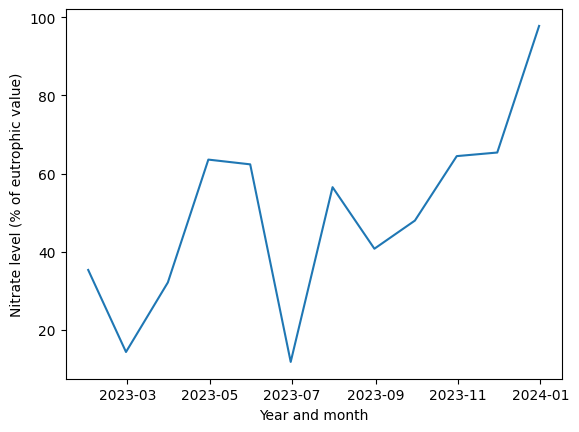

In [131]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/var/folders/v5/yddrf7t17gj_q1nfvqx_2sfm0000gn/T/ipykernel_94304/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

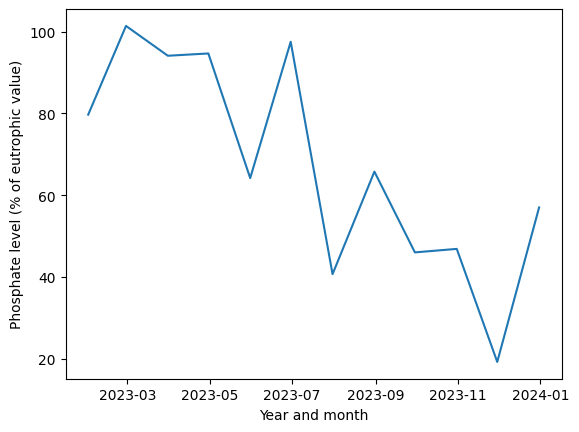

In [132]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

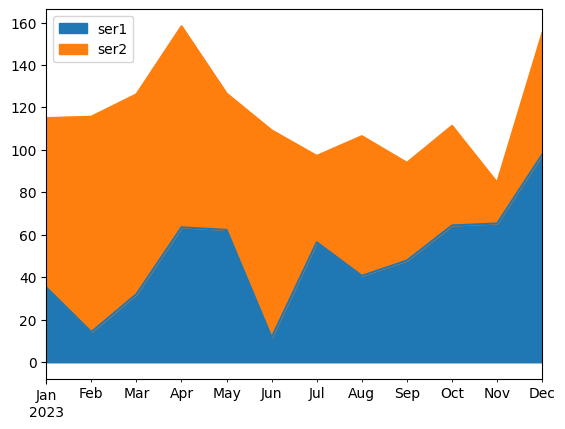

In [133]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

In [134]:
# enable the view of all the columns in the dataset
pd.set_option('display.max_columns', None)

df = pd.read_csv('datasets/risk_factors_cervical_cancer.csv', na_values=['?'])

In [135]:
df.head(10)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.000000,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.000000,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
5,42,3.0,23.0,2.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
6,51,3.0,17.0,6.0,1.0,34.000000,3.4,0.0,0.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,1,1,0,1
7,26,1.0,26.0,3.0,0.0,0.000000,0.0,1.0,2.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
8,45,1.0,20.0,5.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,1,0,0,0,0
9,44,3.0,15.0,NaN,1.0,1.266973,2.8,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [137]:
df.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,832.000000,851.000000,802.000000,845.000000,845.000000,845.000000,750.000000,750.000000,741.000000,741.000000,753.000000,753.000000,753.000000,753.0,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.0,753.000000,753.000000,753.000000,858.000000,71.000000,71.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,2.527644,16.995300,2.275561,0.145562,1.219721,0.453144,0.641333,2.256419,0.112011,0.514804,0.104914,0.176627,0.058433,0.0,0.005312,0.057105,0.023904,0.001328,0.001328,0.001328,0.0,0.023904,0.001328,0.002656,0.087413,6.140845,5.816901,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,1.667760,2.803355,1.447414,0.352876,4.089017,2.226610,0.479929,3.764254,0.315593,1.943089,0.306646,0.561993,0.234716,0.0,0.072739,0.232197,0.152853,0.036442,0.036442,0.036442,0.0,0.152853,0.036442,0.051503,0.302545,5.895024,5.755271,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,8.000000,7.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,19.000000,1.000000,4.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,3.000000,22.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [138]:
df.isna().sum()

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

In [139]:
# identify the average number of nulls per column
missing_ratio = df.isnull().mean()

# drop columns where significant data is missing and imput numeric means columns with low null thresholds 
df = df.drop(columns=missing_ratio[missing_ratio > 0.8].index)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [140]:
df[['First sexual intercourse']].value_counts()

First sexual intercourse
15.0000                     163
17.0000                     151
18.0000                     137
16.0000                     121
14.0000                      79
19.0000                      60
20.0000                      37
13.0000                      25
21.0000                      20
22.0000                       9
23.0000                       9
16.9953                       7
26.0000                       7
27.0000                       6
12.0000                       6
24.0000                       6
29.0000                       5
28.0000                       3
10.0000                       2
25.0000                       2
11.0000                       2
32.0000                       1
Name: count, dtype: int64

In [141]:
duplicate_rows = df[df.duplicated]
duplicate_rows

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
66,34,3.000000,19.0,3.0,0.0,0.0,0.0,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0
234,25,2.527644,18.0,2.0,0.0,0.0,0.0,0.641333,2.256419,0.112011,0.514804,0.104914,0.176627,0.058433,0.0,0.005312,0.057105,0.023904,0.001328,0.001328,0.001328,0.0,0.023904,0.001328,0.002656,0,0,0,0,0,0,0,0,0
255,25,2.000000,18.0,2.0,0.0,0.0,0.0,1.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0
356,18,1.000000,17.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0
395,18,1.000000,18.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0
406,17,1.000000,17.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0
419,19,4.000000,14.0,1.0,0.0,0.0,0.0,0.641333,2.256419,0.112011,0.514804,0.104914,0.176627,0.058433,0.0,0.005312,0.057105,0.023904,0.001328,0.001328,0.001328,0.0,0.023904,0.001328,0.002656,0,0,0,0,0,0,0,0,0
431,18,1.000000,14.0,2.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0
435,17,2.000000,15.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0
440,15,1.000000,14.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0


In [142]:
len(duplicate_rows)

23

In [143]:
# drop duplicate columns
df = df.drop_duplicates()

<Figure size 2000x2000 with 0 Axes>

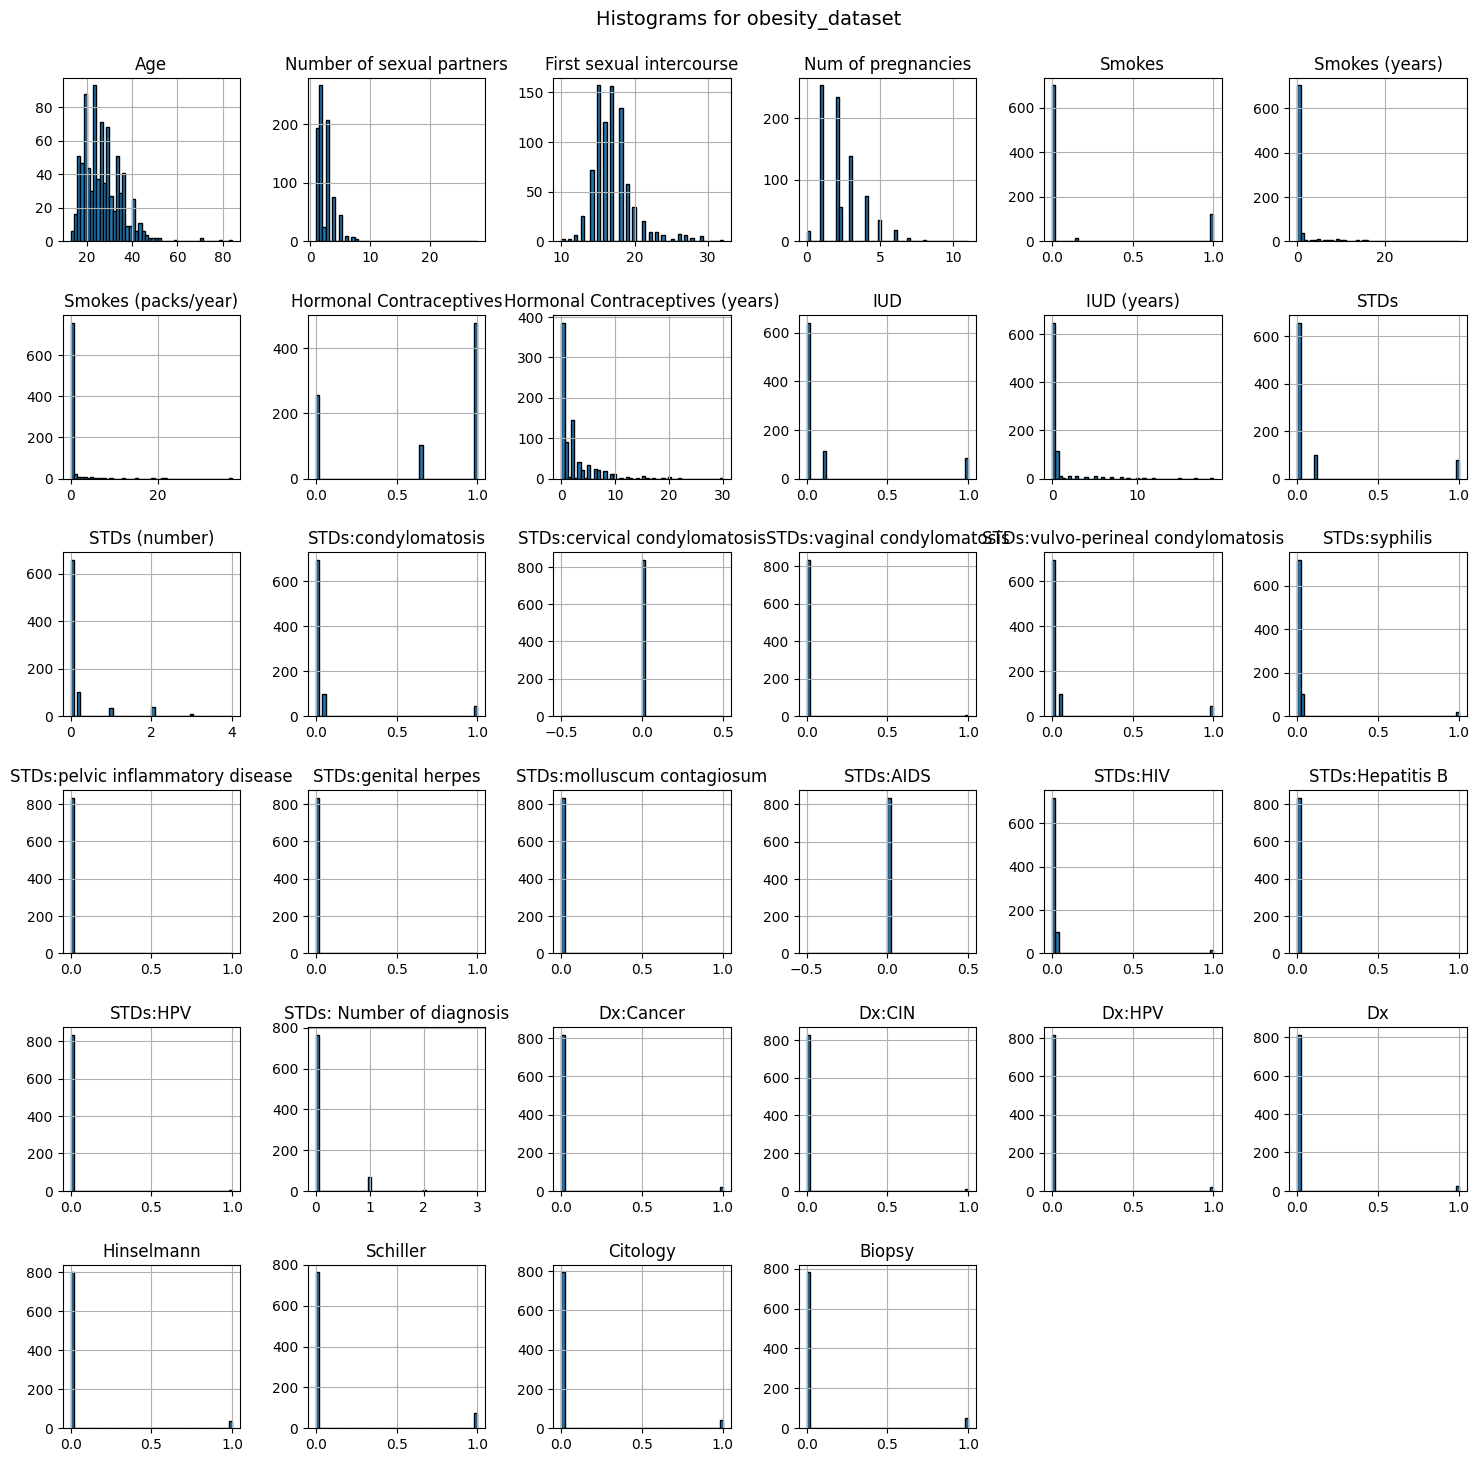

In [144]:
plt.figure(figsize=(20, 20)) 
df.hist(bins=50, figsize=(15, 15), edgecolor='black') 
plt.suptitle(f"Histograms for obesity_dataset", fontsize=14) 
plt.tight_layout(pad=2.0) 
plt.show()

In [145]:
df.corr()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
Age,1.000000,0.070456,0.360902,0.516321,0.046671,0.213664,0.128294,0.040068,0.268514,0.264582,0.203549,0.002871,-0.022465,-0.030738,NaN,0.004757,-0.028236,0.007267,0.022797,-0.030304,-0.001711,NaN,-0.005397,-0.030304,0.038043,-0.008673,0.108519,0.059899,0.099765,0.089979,-0.009050,0.101150,-0.019194,0.054396
Number of sexual partners,0.070456,1.000000,-0.155124,0.066471,0.234569,0.174433,0.173714,-0.009178,0.010697,0.025660,0.000795,0.049834,0.035655,0.031730,NaN,-0.044219,0.033891,0.025382,0.030393,-0.032556,0.030393,NaN,0.018014,-0.011573,0.013317,0.047863,0.020384,0.014335,0.025381,0.020729,-0.042590,-0.017225,0.014124,-0.009540
First sexual intercourse,0.360902,-0.155124,1.000000,-0.069971,-0.128772,-0.061683,-0.058724,0.003826,0.001620,-0.024157,-0.027256,-0.016102,0.003951,0.024976,NaN,0.071462,0.029347,-0.103222,-0.001400,0.023305,-0.013752,NaN,-0.014847,0.010953,0.032981,-0.016080,0.066577,-0.033853,0.043045,0.034548,-0.018570,0.003806,-0.009420,0.008516
Num of pregnancies,0.516321,0.066471,-0.069971,1.000000,0.073629,0.170861,0.093993,0.126555,0.199925,0.194677,0.140607,0.039029,-0.003488,-0.042488,NaN,-0.004404,-0.041636,0.140427,-0.057644,-0.033001,0.040928,NaN,0.006879,-0.033001,-0.029265,0.028263,0.032617,0.005422,0.044353,0.015926,0.035066,0.087076,-0.029784,0.043674
Smokes,0.046671,0.234569,-0.128772,0.073629,1.000000,0.722303,0.492470,-0.010770,0.039598,-0.054827,-0.035669,0.113834,0.103172,0.057716,NaN,0.069101,0.060609,0.081404,-0.014443,-0.014443,-0.014443,NaN,0.058070,0.083403,0.048795,0.092448,-0.012738,-0.044113,0.010561,-0.069752,0.032260,0.052380,-0.004379,0.028462
Smokes (years),0.213664,0.174433,-0.061683,0.170861,0.722303,1.000000,0.723737,-0.017406,0.045663,0.025155,0.036126,0.089481,0.089356,0.043760,NaN,0.113975,0.045899,0.014332,-0.010603,-0.010603,-0.010603,NaN,0.089691,0.099042,0.050643,0.079471,0.053544,-0.031863,0.056088,-0.050382,0.069651,0.094193,-0.007135,0.061442
Smokes (packs/year),0.128294,0.173714,-0.058724,0.093993,0.492470,0.723737,1.000000,0.001780,0.037916,0.006214,0.014671,0.027812,0.029348,0.006750,NaN,0.041093,0.007979,-0.004019,-0.007357,-0.007357,-0.007357,NaN,0.053886,0.100994,-0.008659,0.030605,0.107743,-0.021724,0.109635,-0.034351,0.025526,0.017231,0.004467,0.024426
Hormonal Contraceptives,0.040068,-0.009178,0.003826,0.126555,-0.010770,-0.017406,0.001780,1.000000,0.444103,0.026609,-0.040248,-0.040228,-0.045714,-0.014898,NaN,-0.061938,-0.019349,-0.007104,0.027314,0.027314,-0.050312,NaN,-0.081153,-0.050312,0.038654,-0.057618,0.023907,-0.005511,0.035762,-0.005241,0.029969,-0.004532,-0.008298,0.009607
Hormonal Contraceptives (years),0.268514,0.010697,0.001620,0.199925,0.039598,0.045663,0.037916,0.444103,1.000000,0.091076,-0.002846,-0.003401,-0.010393,0.004712,NaN,-0.039274,0.006691,0.001981,-0.014719,-0.019597,-0.022036,NaN,-0.037566,-0.022036,0.051644,-0.040788,0.053171,0.001901,0.059969,-0.014900,0.036611,0.078773,0.076280,0.080162
IUD,0.264582,0.025660,-0.024157,0.194677,-0.054827,0.025155,0.006214,0.026609,0.091076,1.000000,0.745959,0.051019,0.050536,0.075259,NaN,0.031506,0.059854,-0.023724,-0.013465,-0.013465,-0.013465,NaN,0.007236,-0.013465,-0.019056,0.027564,0.109539,0.051072,0.057054,0.137778,0.042451,0.083917,0.007595,0.051825


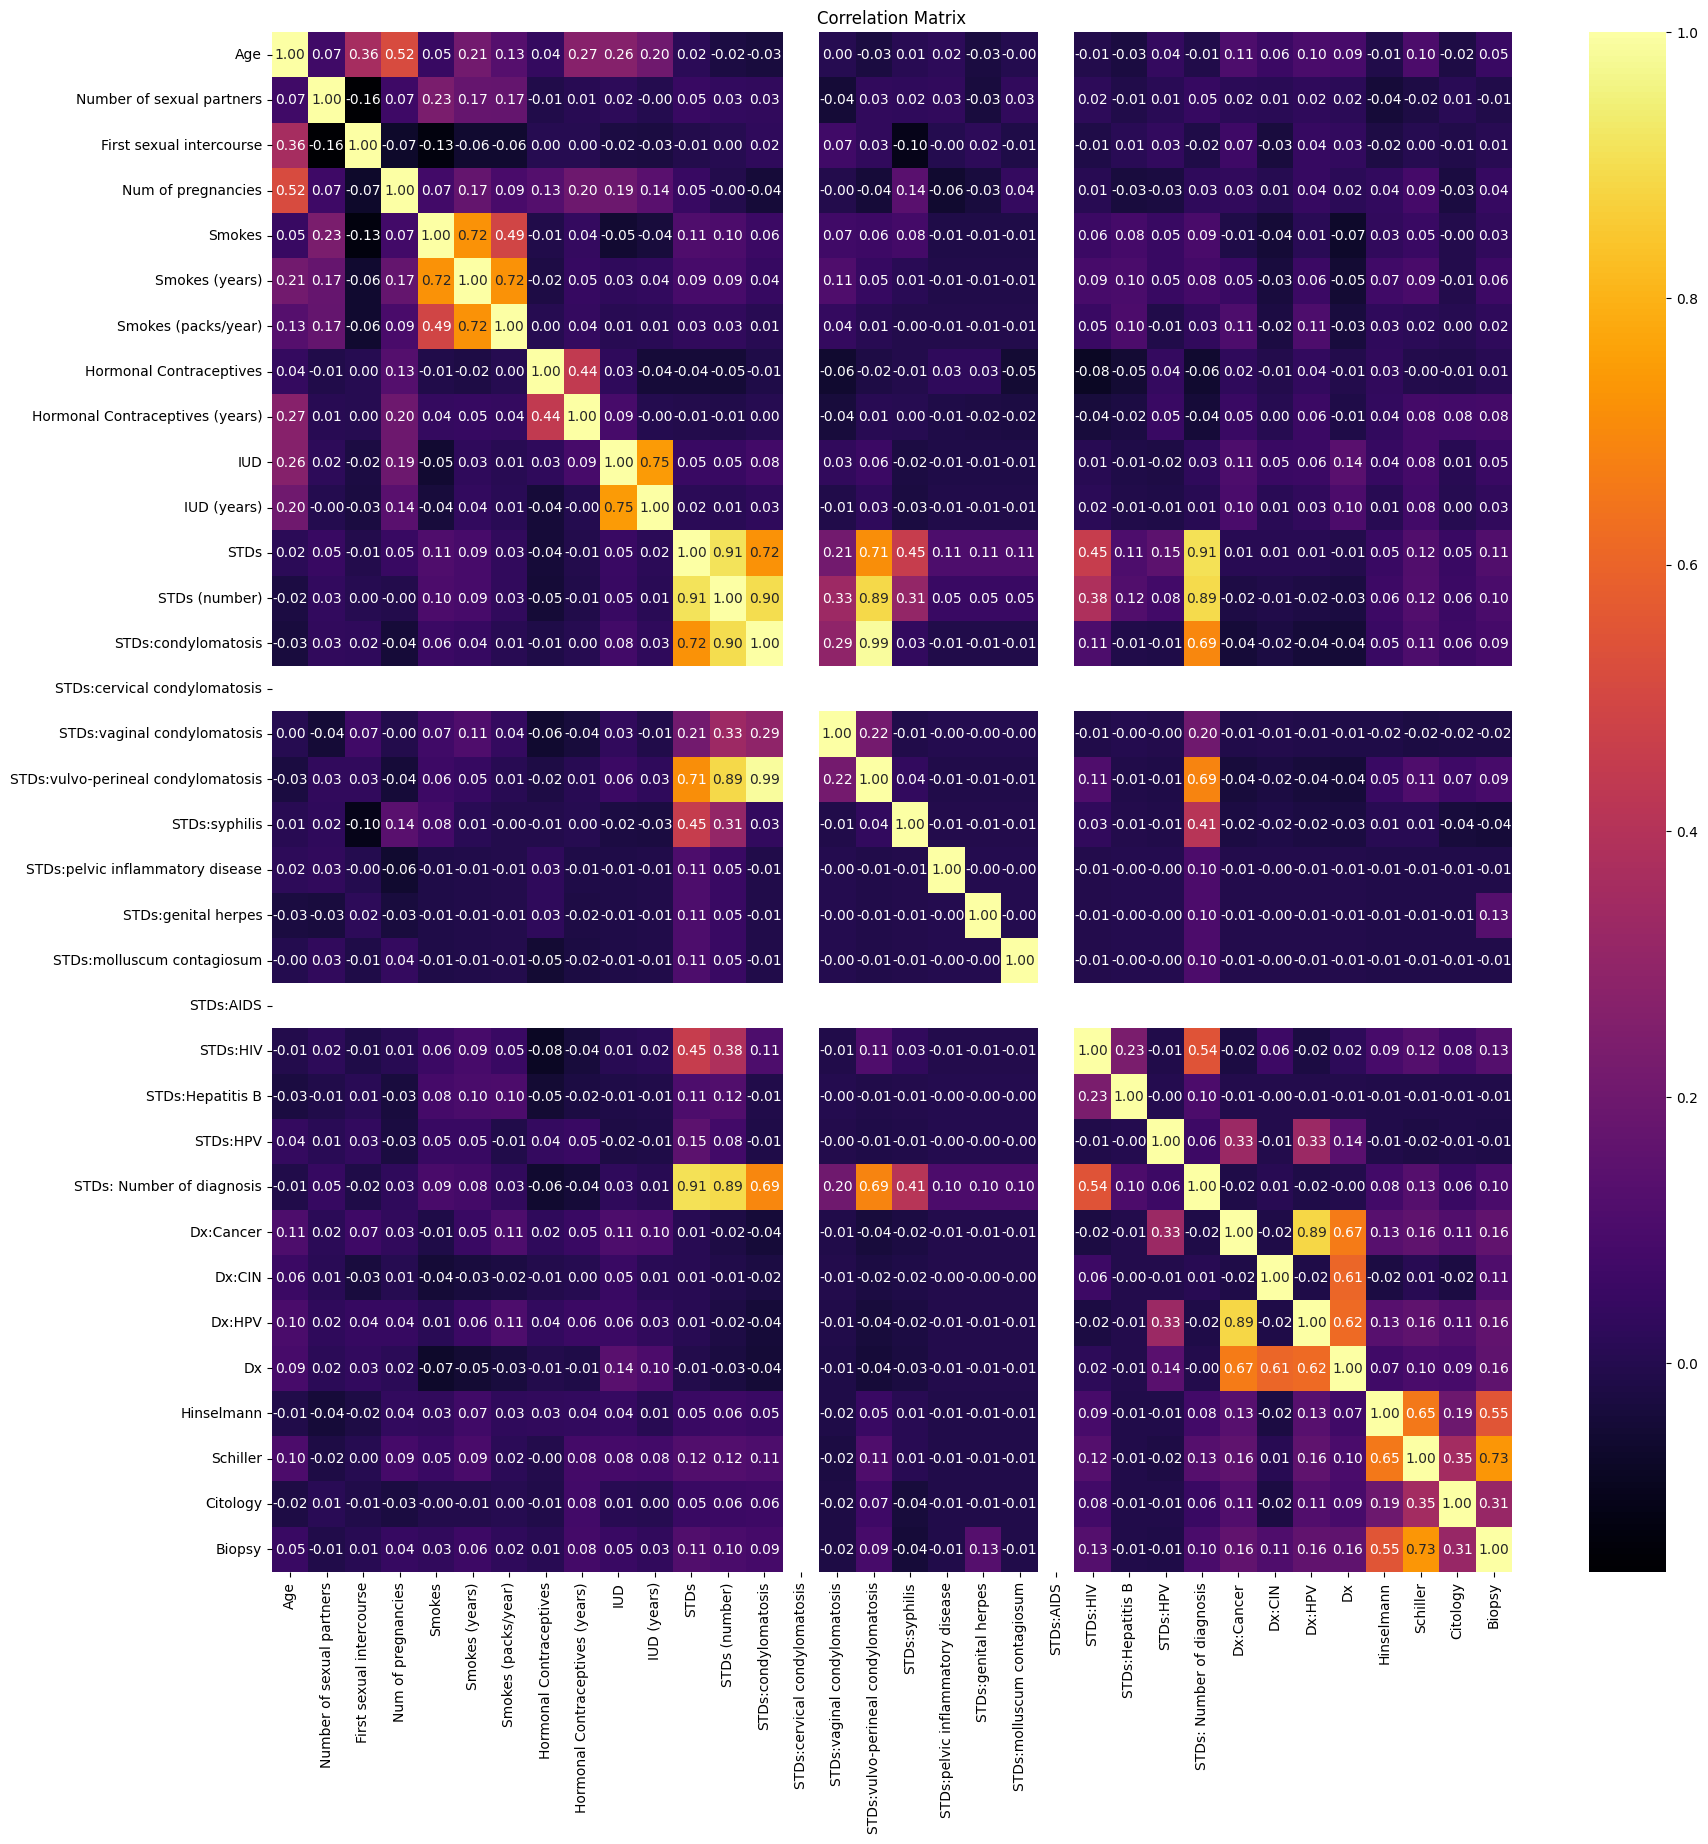

In [196]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='inferno')
plt.title("Correlation Matrix")
plt.show()

/Users/wadieabbas/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/wadieabbas/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


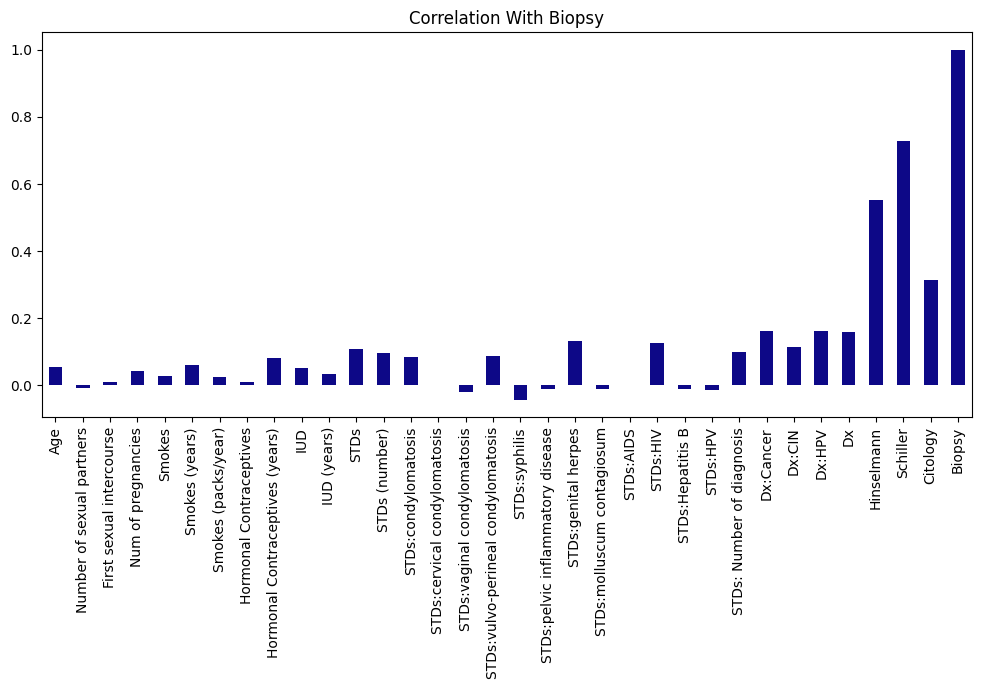

In [161]:
df.corrwith(df['Biopsy']).plot.bar(
    title = 'Correlation With Biopsy', 
    figsize = (12, 5), 
    cmap = 'plasma'
)
plt.show()

In [149]:
X  = df.drop('Biopsy', axis = 1)
y = df['Biopsy']


In [153]:
X.columns


Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology'],
      dtype='object')

In [154]:
print("X size: ", len(X.columns))

X size:  33


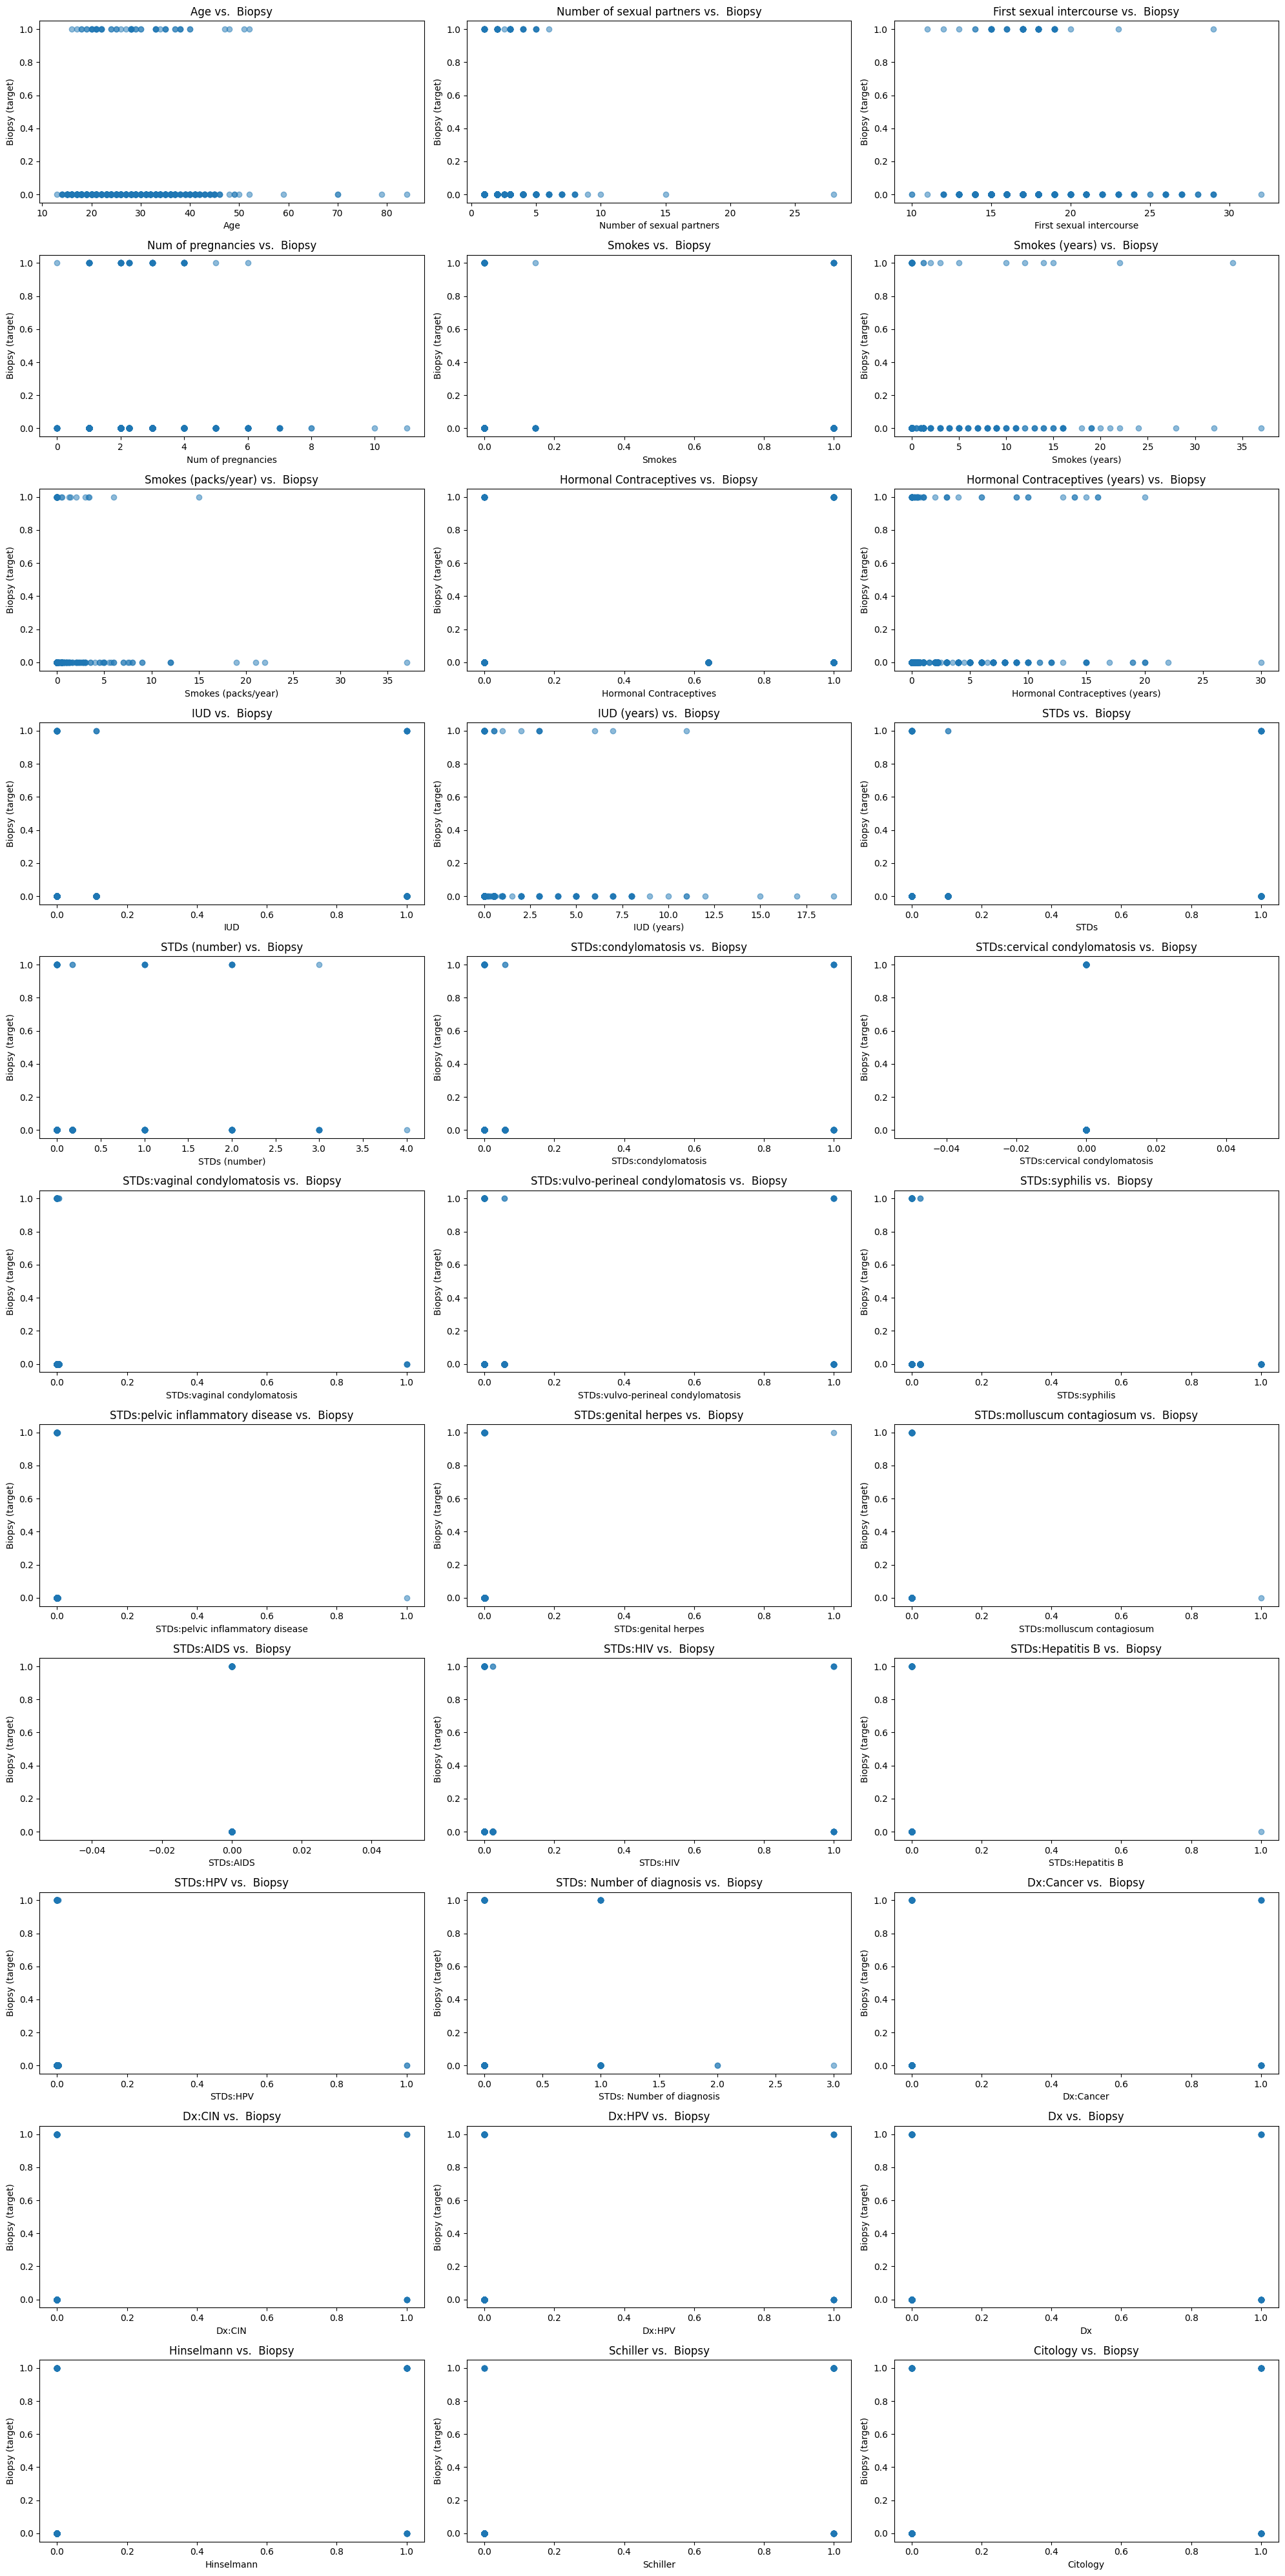

In [158]:

# plot all features against the target variable
plt.figure(figsize=(20, 40))

for i, column in enumerate(X.columns):
    plt.subplot(11, 3, i + 1)
    plt.scatter(df[column], y, alpha=0.5)
    plt.title(column+' vs. '+' Biopsy')
    plt.xlabel(column)
    plt.ylabel('Biopsy (target)')
    plt.tight_layout()

In [ ]:
# identify outliers in the number of sexual partners

std_dev_threshold = 3

df['z-score'] = zscore(df['Number of sexual partners'])
num_sex_partners = df[['Number of sexual partners', 'Age']].copy()
num_sex_partners['z-score'] = np.abs(zscore(df['Number of sexual partners'], nan_policy='omit'))
outliers = num_sex_partners[num_sex_partners['z-score'] > std_dev_threshold]
non_outliers = num_sex_partners[num_sex_partners['z-score'] <= std_dev_threshold]

# df_num_of_sex_partners_outliers =  df['Number of sexual partners']

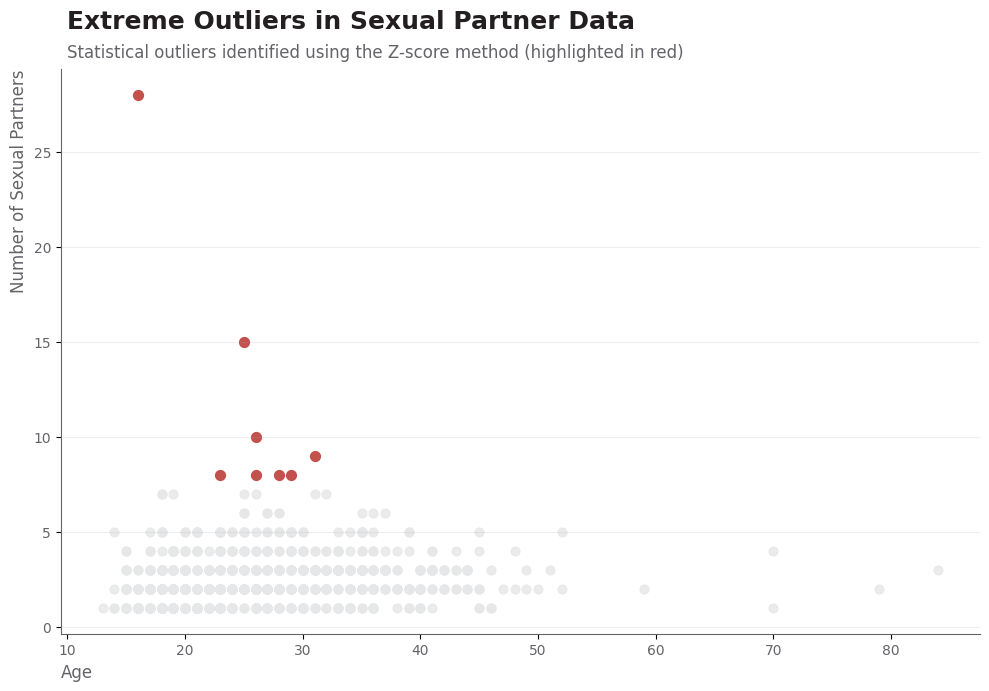

In [ ]:
# my code before AI assitance 

# plt.figure(figsize=(10,8))
# plt.scatter(non_outliers['Age'], non_outliers['Number of sexual partners'])
# plt.scatter(outliers['Age'], outliers['Number of sexual partners'], color='red', marker='o')
# plt.xlabel('Age')
# plt.ylabel('Sexual Partners')
# plt.tight_layout()

# AI enhanced 

# 1. Setup the figure and colors
GRAY1, GRAY4, GRAY9 = '#231F20', '#646369', '#E6E7E8'
RED1 = '#C3514E'

plt.figure(figsize=(10, 7), facecolor='white')
ax = plt.subplot(111)

# 2. Plotting (Non-outliers in neutral gray, Outliers in focal red)
plt.scatter(non_outliers['Age'], non_outliers['Number of sexual partners'], 
            color=GRAY9, s=40, label='Normal Range', alpha=0.8)

plt.scatter(outliers['Age'], outliers['Number of sexual partners'], 
            color=RED1, s=50, marker='o', label='Outliers')

# 3. Remove chart junk (Spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRAY4)
ax.spines['bottom'].set_color(GRAY4)

# 4. Refine Axis Labels
plt.xlabel('Age', loc='left', color=GRAY4, fontsize=12)
plt.ylabel('Number of Sexual Partners', loc='top', color=GRAY4, fontsize=12)

# 5. Strategic Titling (Left-aligned)
plt.text(10, 31.5, 'Extreme Outliers in Sexual Partner Data', 
         fontsize=18, color=GRAY1, fontweight='bold')
plt.text(10, 30, 'Statistical outliers identified using the Z-score method (highlighted in red)', 
         fontsize=12, color=GRAY4)

# 6. Final Polish
plt.xticks(color=GRAY4)
plt.yticks(color=GRAY4)
plt.grid(axis='y', linestyle='-', alpha=0.2) # Light horizontal grid for scale
plt.tight_layout()

plt.show()

In [164]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

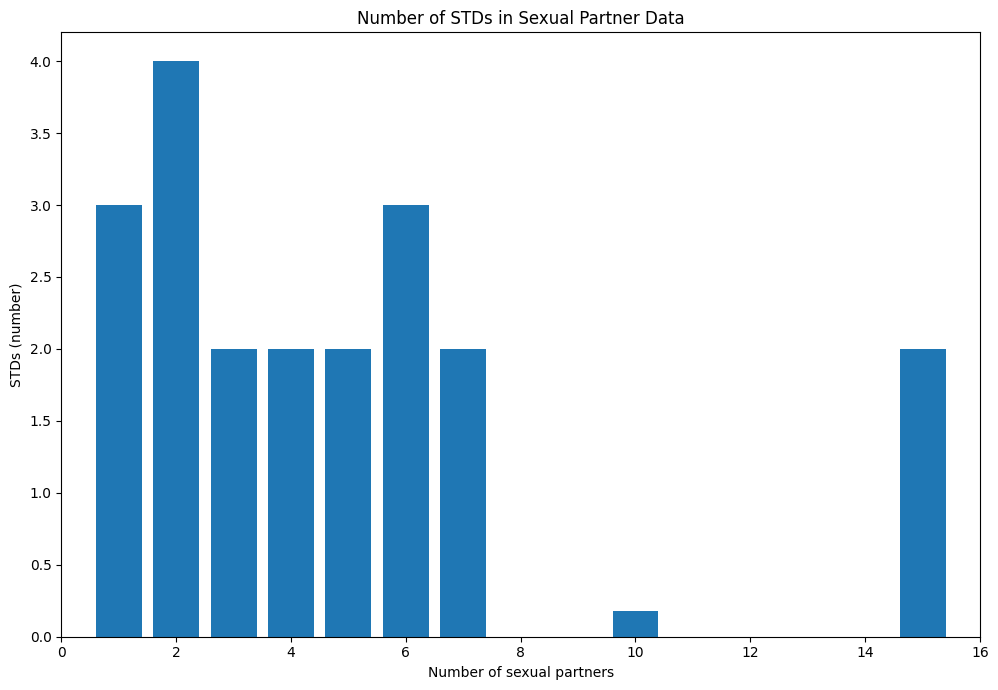

In [ ]:
# clean up weird data
df['Number of sexual partners'] = np.round(df['Number of sexual partners'], 0)

# plot number of partners by std count
plt.figure(figsize=(10, 7))
plt.bar(df['Number of sexual partners'], df['STDs (number)'])
plt.title('Number of STDs in Sexual Partner Data')

plt.xlabel('Number of sexual partners')
plt.ylabel('STDs (number)')
plt.tight_layout()
plt.xlim(0, 16)
plt.show()

In [ ]:
# clean up weird data
df['Number of sexual partners'] = np.round(df['Number of sexual partners'], 0)

plt.figure(figsize=(10, 7))
plt.bar(df['Number of sexual partners'], df['STDs (number)'])
plt.title('Number of STDs in Sexual Partner Data')

plt.xlabel('Number of sexual partners')
plt.ylabel('STDs (number)')
plt.tight_layout()
plt.xlim(0, 16)
plt.show()

0      0
1      0
2      0
3      0
4      0
      ..
853    0
854    0
855    0
856    0
857    0
Name: Biopsy, Length: 835, dtype: int64

In [194]:
df['STDs'] = df['STDs'].round(0)

std_analysis = df.groupby('Number of sexual partners')['STDs'].value_counts().to_frame().reset_index()
std_analysis

,Number of sexual partners,STDs,count
0,1.0,0.0,178
1,1.0,1.0,15
2,2.0,0.0,242
3,2.0,1.0,24
4,3.0,0.0,207
5,3.0,1.0,25
6,4.0,0.0,70
7,4.0,1.0,6
8,5.0,0.0,39
9,5.0,1.0,5


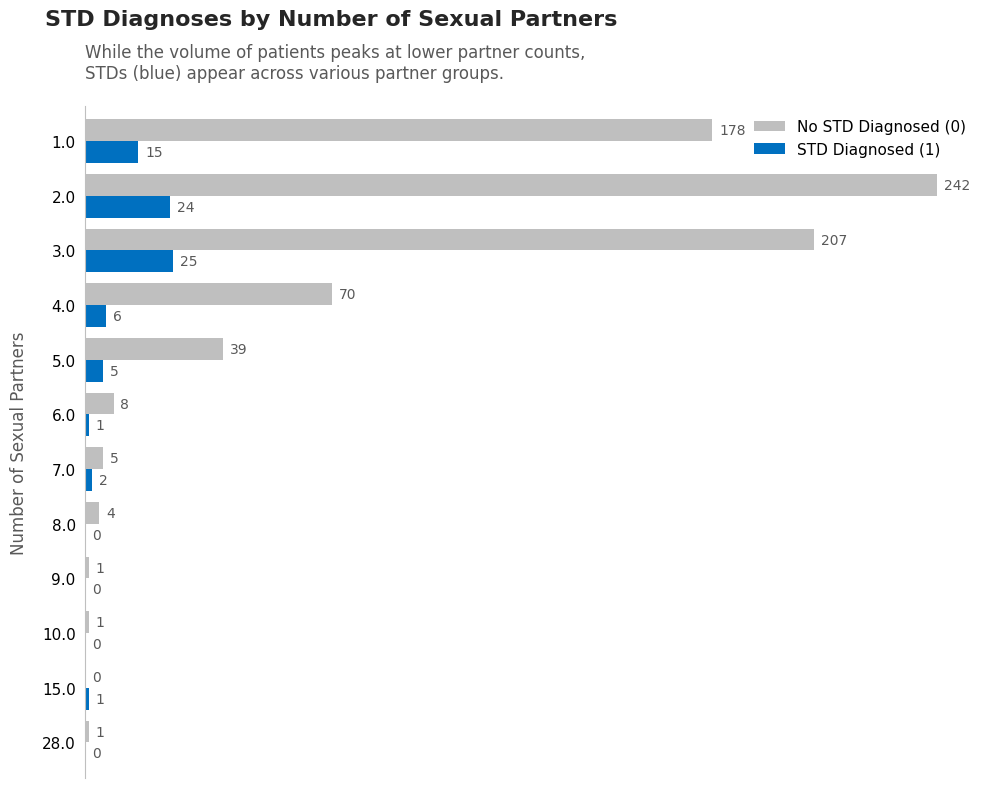

In [195]:
# 1. Prepare the data (Pivot so it's easy to plot grouped bars)
# Assuming 'count' is the name of the column generated by value_counts().reset_index()
# If pandas named it differently (like 'STDs' in older versions), change 'count' to that name.
plot_data = std_analysis.pivot(
    index='Number of sexual partners', 
    columns='STDs', 
    values='count'
).fillna(0)

# 2. Set up the figure
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Plot the data
# SWD Principle: Strategic use of color. Muted grey for 'No STD' (0), standout blue for 'STD' (1)
colors = ['#BFBFBF', '#0070C0'] 
plot_data.plot(kind='barh', ax=ax, color=colors, width=0.8)

# 4. Declutter the chart (SWD Principles)
# Remove top, right, and bottom spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('#BFBFBF') # Mute the y-axis line

# Remove x-axis tick marks and labels (we will use direct data labels instead)
ax.set_xticks([])
ax.tick_params(axis='y', left=False, labelsize=11, color='#595959')

# 5. Add Direct Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, color='#595959')

# 6. Adjust Legend
# SWD Principle: Make legends unobtrusive or integrate them.
legend = ax.legend(
    title='', 
    labels=['No STD Diagnosed (0)', 'STD Diagnosed (1)'],
    loc='upper right', 
    frameon=False, 
    fontsize=11
)

# 7. Add Title and Labels (Left-aligned, active title)
# SWD Principle: Use a descriptive, left-aligned title to state the takeaway.
plt.suptitle(
    'STD Diagnoses by Number of Sexual Partners', 
    x=0.05, y=0.98, ha='left', fontsize=16, fontweight='bold', color='#262626'
)
plt.title(
    'While the volume of patients peaks at lower partner counts, \nSTDs (blue) appear across various partner groups.', 
    loc='left', fontsize=12, color='#595959', pad=20
)

ax.set_ylabel('Number of Sexual Partners', fontsize=12, color='#595959', labelpad=10)

# Invert y-axis so the lowest number of partners is at the top
ax.invert_yaxis()

# Show the clean plot
plt.tight_layout()
plt.show()

# My Conclusions

> Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- The data is usable. There are some funky things in the data ranging from "?" instead of Nans, duplicates, columns with high null counts, and inaccurate data. For example, the STDs boolean had a float in it even though this is a boolean. There seemed to be multiple target variables in the data as well, but from what I researched online most people use the 'Biopsy' variable as the main target variable dropping the others. 

> Do you see any outliers?  (Data points that are far from the rest of the data).

- I did see outliers. I used a scatter plot to show case instances of a high sex partner count greater than 3 standard deviations above the mean. Depending on the model used these outliers should be considered being dropped. 

> Are any data items highly correlated with each other, suggesting that they are redundant?

- Yes, there are a few features in the dataset that seem to be redundant or correlated with one another:
        - STDs and the number of STDs
        - Smokes, Smokes Year, and Smokes Per Year
        - IUD and IUD years

> For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- This data is not timeseries based data since it seems to be more so a one time survey. I did not use line plots, but I mainly used bar charts and scatter plots here. 

> Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

- There could be a correlation with the types of sex people, sexual orientation, race, and other variables that may make cervical cancer more or less likely in general. The dataset as is, seems to have some of the confounding variables where we see correlations amongst the features alread captured in the dataset. 